# Monte Carlo Method for Calculating Pi
## Pi Day 2026

To celebrate Pi Day, I wrote a small program that estimates the value of π using the Monte Carlo method.

The idea is simple: random points are generated inside a square, and we count how many of them fall inside a quarter of a circle. By comparing the number of points inside the circle to the total number of points, we can approximate the value of pi.

With enough random samples, the approximation gradually converges to the real value of π.

In [80]:
import numpy as np
import matplotlib.pyplot as plt

In [81]:
PROBES = 100_000_000
PROBES_TO_SHOW = 2500

In [82]:
x_points = np.random.rand(PROBES)
y_points = np.random.rand(PROBES)

d = x_points * x_points + y_points * y_points

inside = d <= 1
outside = d > 1


calc_pi = 4 * np.sum(inside) / PROBES

In [83]:
print(f"Calculated pi: {calc_pi}")
print(f"Squared error: {(np.pi - calc_pi) ** 2}")

Calculated pi: 3.14131972
Squared error: 7.449274443745763e-08


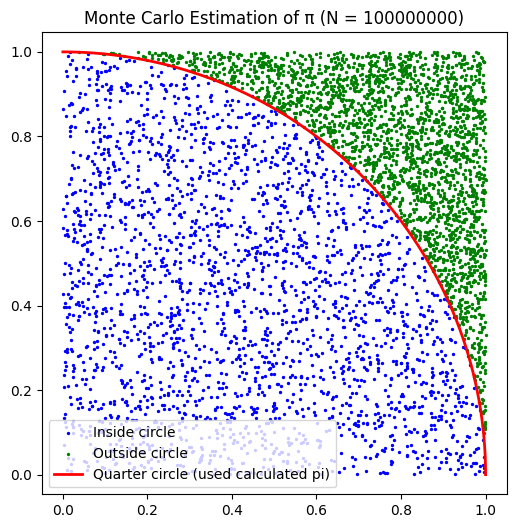

In [88]:
plt.figure(figsize=(6,6))

plt.scatter(
  x_points[inside][:PROBES_TO_SHOW],
  y_points[inside][:PROBES_TO_SHOW],
  s=2, c="b",
  label=f"Inside circle"
)

plt.scatter(
    x_points[outside][:PROBES_TO_SHOW],
y_points[outside][:PROBES_TO_SHOW],
  s=2,
  c="g",
  label=f"Outside circle"
)

theta = np.linspace(0, 0.5 * calc_pi, 500)
plt.plot(
  np.cos(theta),
  np.sin(theta),
  c="r",
  lw=2,
  label="Quarter circle (used calculated pi)"
)

plt.axis("equal")
plt.legend()
plt.title(f"Monte Carlo Estimation of π (N = {PROBES})")
plt.show()